# 🏦 Loan Approval Prediction

## 📌 Problem Statement

Financial institutions receive thousands of loan applications every day. Manually reviewing each application is time-consuming and may lead to inconsistent decisions.

The objective of this project is to build a Machine Learning model that predicts whether a loan application should be approved based on the applicant's demographic details, financial status, employment information, credit history, and other relevant features.

The developed model can help banks and financial institutions automate the loan approval process, reduce risk, and improve decision-making efficiency.

In [51]:
# import dataset    
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [52]:
import pandas as pd

df = pd.read_csv('../data/loan_approval_dataset.csv')
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


### remove space

In [53]:
df.columns = df.columns.str.strip()

In [54]:
## EDA
from IPython.display import display
import pandas as pd

print('='*60)
print('📊 EXPLORATORY DATA ANALYSIS (EDA) SUMMARY')
print('='*60)

print('\n📌 Dataset Shape')
print(df.shape)

print('\n📌 First 5 Rows')
display(df.head())

print('\n📌 Last 5 Rows')
display(df.tail())

print('\n📌 Random Sample')
display(df.sample(5))

print('\n📌 Column Names')
display(pd.DataFrame(df.columns, columns=['Columns']))

print('\n📌 Data Types')
display(df.dtypes.to_frame('Data Type'))

print('\n📌 Dataset Information')
df.info()

print('\n📌 Missing Values')
display(df.isnull().sum().to_frame('Missing Values'))

print('\n📌 Duplicate Rows')
print(df.duplicated().sum())

print('\n📌 Numerical Summary')
display(df.describe().T)

print('\n📌 Categorical Summary')
display(df.describe(include='object').T)

print('\n📌 Correlation Matrix')
display(df.corr(numeric_only=True))

print('\n✅ EDA Completed Successfully!')

📊 EXPLORATORY DATA ANALYSIS (EDA) SUMMARY

📌 Dataset Shape
(4269, 13)

📌 First 5 Rows


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected



📌 Last 5 Rows


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved
4268,4269,1,Graduate,No,9200000,29700000,10,607,17800000,11800000,35700000,12000000,Approved



📌 Random Sample


...


📌 Categorical Summary


,count,unique,top,freq
education,4269,2,Graduate,2144
self_employed,4269,2,Yes,2150
loan_status,4269,2,Approved,2656



📌 Correlation Matrix


,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
loan_id,1.000000,0.005326,0.012592,0.008170,0.009809,0.016323,0.020936,0.018595,-0.000862,0.010765
no_of_dependents,0.005326,1.000000,0.007266,-0.003366,-0.020111,-0.009998,0.007376,-0.001531,0.002817,0.011163
income_annum,0.012592,0.007266,1.000000,0.927470,0.011488,-0.023034,0.636841,0.640328,0.929145,0.851093
loan_amount,0.008170,-0.003366,0.927470,1.000000,0.008437,-0.017035,0.594596,0.603188,0.860914,0.788122
loan_term,0.009809,-0.020111,0.011488,0.008437,1.000000,0.007810,0.008016,-0.005478,0.012490,0.017177
cibil_score,0.016323,-0.009998,-0.023034,-0.017035,0.007810,1.000000,-0.019947,-0.003769,-0.028618,-0.015478
residential_assets_value,0.020936,0.007376,0.636841,0.594596,0.008016,-0.019947,1.000000,0.414786,0.590932,0.527418
commercial_assets_value,0.018595,-0.001531,0.640328,0.603188,-0.005478,-0.003769,0.414786,1.000000,0.591128,0.548576
luxury_assets_value,-0.000862,0.002817,0.929145,0.860914,0.012490,-0.028618,0.590932,0.591128,1.000000,0.788517
bank_asset_value,0.010765,0.011163,0.851093,0.788122,0.017177,-0.015478,0.527418,0.548576,0.788517,1.000000



✅ EDA Completed Successfully!


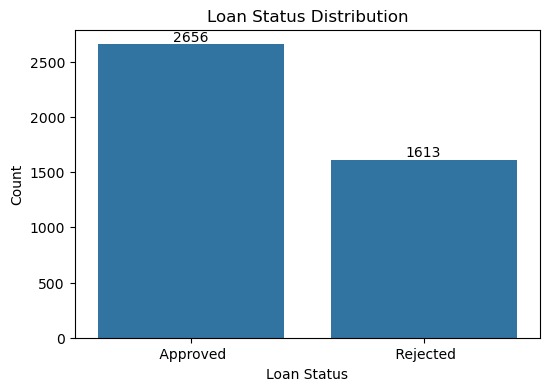

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

ax = sns.countplot(
    x='loan_status',
    data=df
)

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [56]:
(df["loan_status"].value_counts(normalize=True) * 100).round(2)

loan_status
Approved    62.22
Rejected    37.78
Name: proportion, dtype: float64

## Target Variable Analysis

The target variable is slightly imbalanced.

- Approved Loans : 62.22%
- Rejected Loans : 37.78%

The class distribution is acceptable for training machine learning models. Initially, models will be trained without any resampling techniques. If the minority class performance is poor, techniques such as SMOTE will be considered during model improvement.

## Numerical Feature Analysis

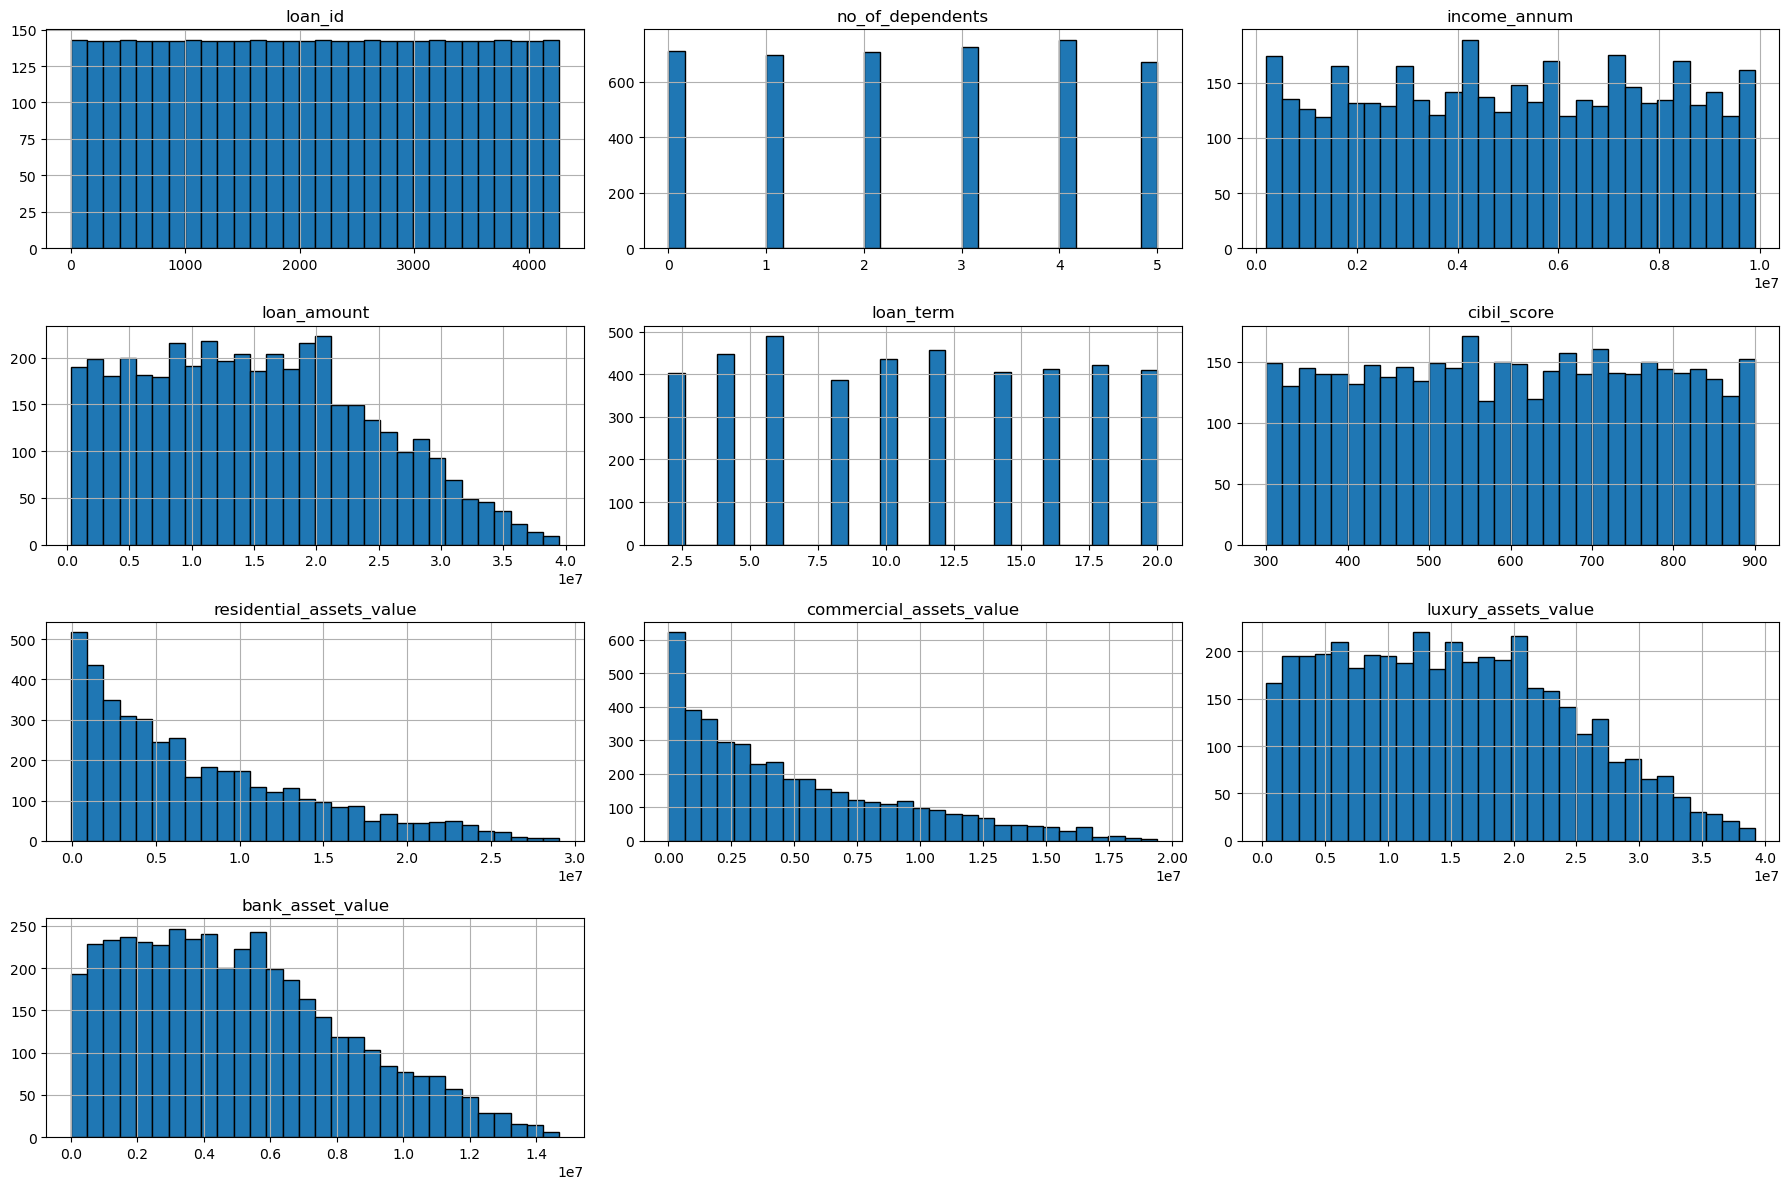

In [57]:
numerical_cols = [feature for feature in df.columns if df[feature].dtype != 'O']

df[numerical_cols].hist(
    figsize=(18,12),
    bins=30,
    edgecolor="black"
)

plt.tight_layout()
plt.show()

## Numerical Feature Analysis

- `no_of_dependents`, `loan_term`, and `cibil_score` show well-distributed values.
- `loan_amount` has a moderate right-skew, indicating that smaller loans are more common than larger ones.
- Asset-related features (`residential_assets_value`, `commercial_assets_value`, `luxury_assets_value`, and `bank_asset_value`) exhibit right-skewed distributions, with most applicants having relatively lower asset values.
- `income_annum` is fairly well distributed across different income ranges.
- CIBIL score covers the complete credit score range, making it a potentially strong predictor for loan approval.

## Categorical Feature analysis 

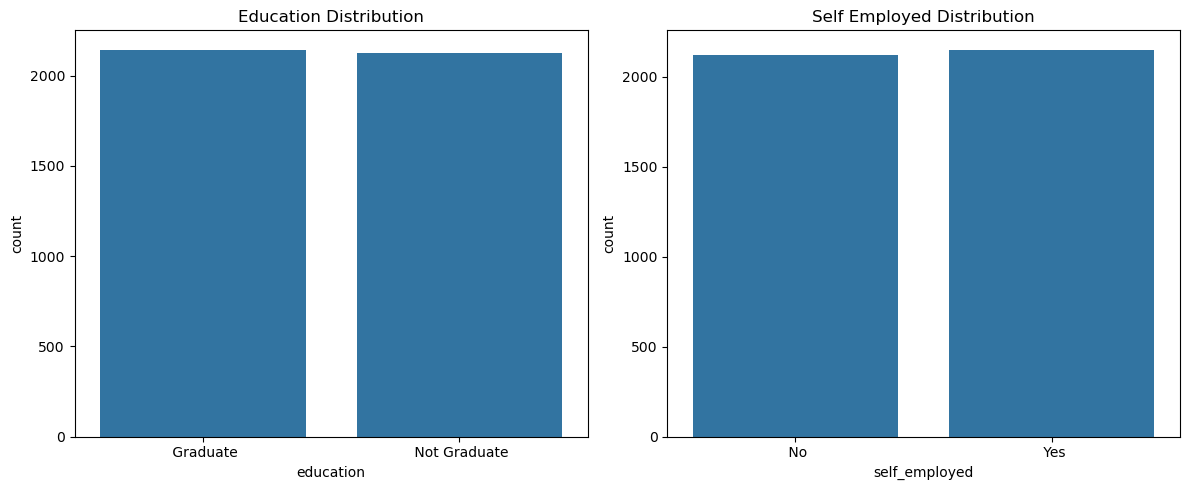

In [58]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x="education", data=df, ax=ax[0])
ax[0].set_title("Education Distribution")

sns.countplot(x="self_employed", data=df, ax=ax[1])
ax[1].set_title("Self Employed Distribution")

plt.tight_layout()
plt.show()


## Categorical Feature Analysis

- The dataset is well balanced with respect to education.
- Graduate and Not Graduate applicants are nearly equal in number.
- Self-employed and non-self-employed applicants are also evenly distributed.
- Since both categorical features are balanced, they are unlikely to introduce sampling bias into the model.

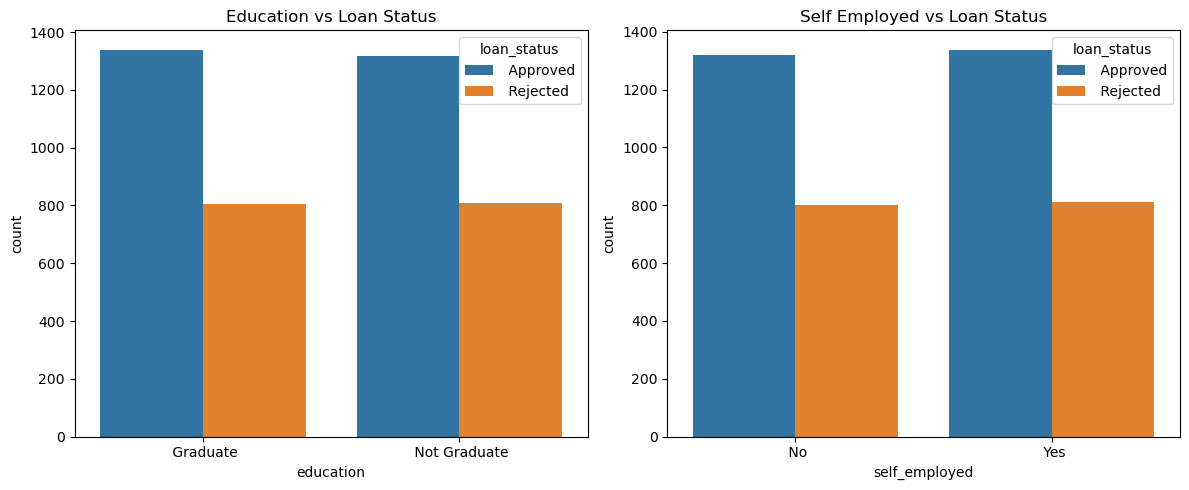

In [59]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.countplot(x='education', hue='loan_status', data=df)
plt.title("Education vs Loan Status")

plt.subplot(1,2,2)
sns.countplot(x='self_employed', hue='loan_status', data=df)
plt.title("Self Employed vs Loan Status")

plt.tight_layout()
plt.show()

## Education & Self Employment vs Loan Status

- Loan approval rates are nearly identical for Graduate and Not Graduate applicants.
- Self-employed and non-self-employed applicants also show very similar approval rates.
- These categorical features alone do not appear to have a strong influence on loan approval decisions.
- More influential numerical features such as CIBIL score, annual income, loan amount, and asset values are likely to play a greater role.

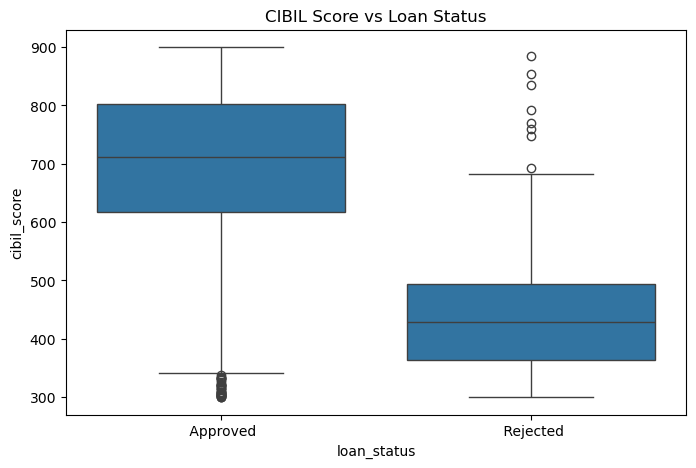

In [60]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="loan_status",
    y="cibil_score",
    data=df
)

plt.title("CIBIL Score vs Loan Status")
plt.show()

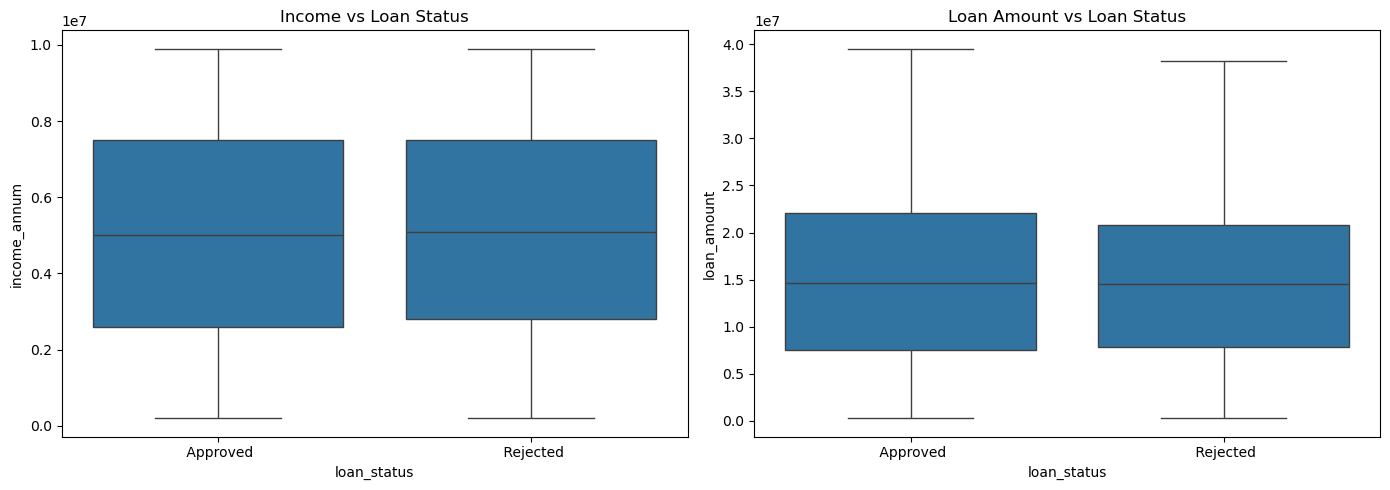

In [61]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.boxplot(
    x="loan_status",
    y="income_annum",
    data=df
)
plt.title("Income vs Loan Status")

plt.subplot(1,2,2)
sns.boxplot(
    x="loan_status",
    y="loan_amount",
    data=df
)
plt.title("Loan Amount vs Loan Status")

plt.tight_layout()
plt.show()

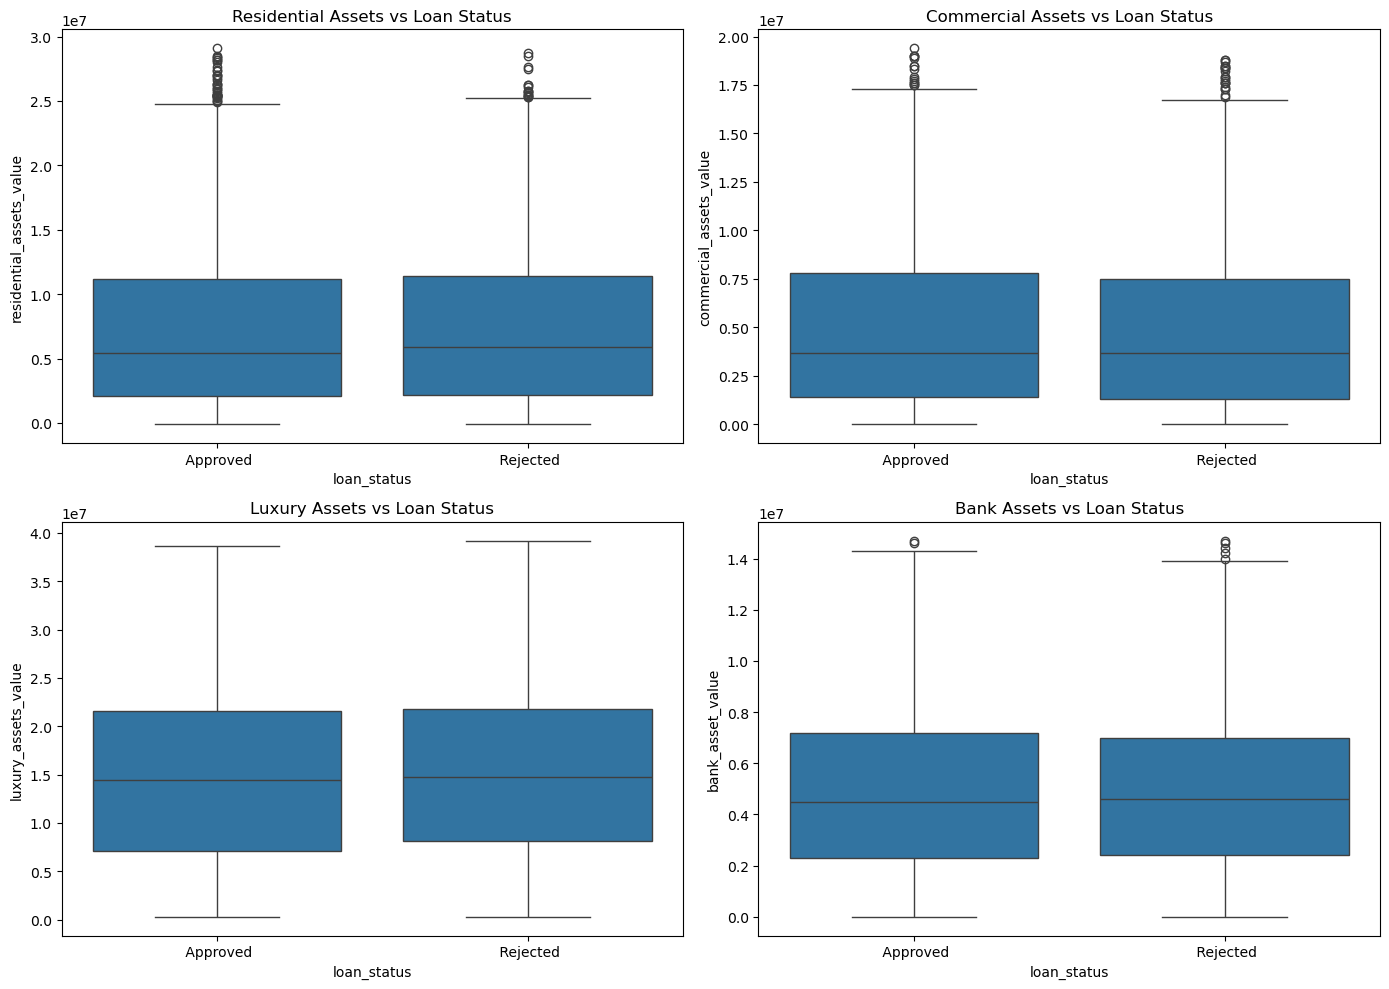

In [62]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(x="loan_status", y="residential_assets_value", data=df, ax=ax[0,0])
ax[0,0].set_title("Residential Assets vs Loan Status")

sns.boxplot(x="loan_status", y="commercial_assets_value", data=df, ax=ax[0,1])
ax[0,1].set_title("Commercial Assets vs Loan Status")

sns.boxplot(x="loan_status", y="luxury_assets_value", data=df, ax=ax[1,0])
ax[1,0].set_title("Luxury Assets vs Loan Status")

sns.boxplot(x="loan_status", y="bank_asset_value", data=df, ax=ax[1,1])
ax[1,1].set_title("Bank Assets vs Loan Status")

plt.tight_layout()
plt.show()

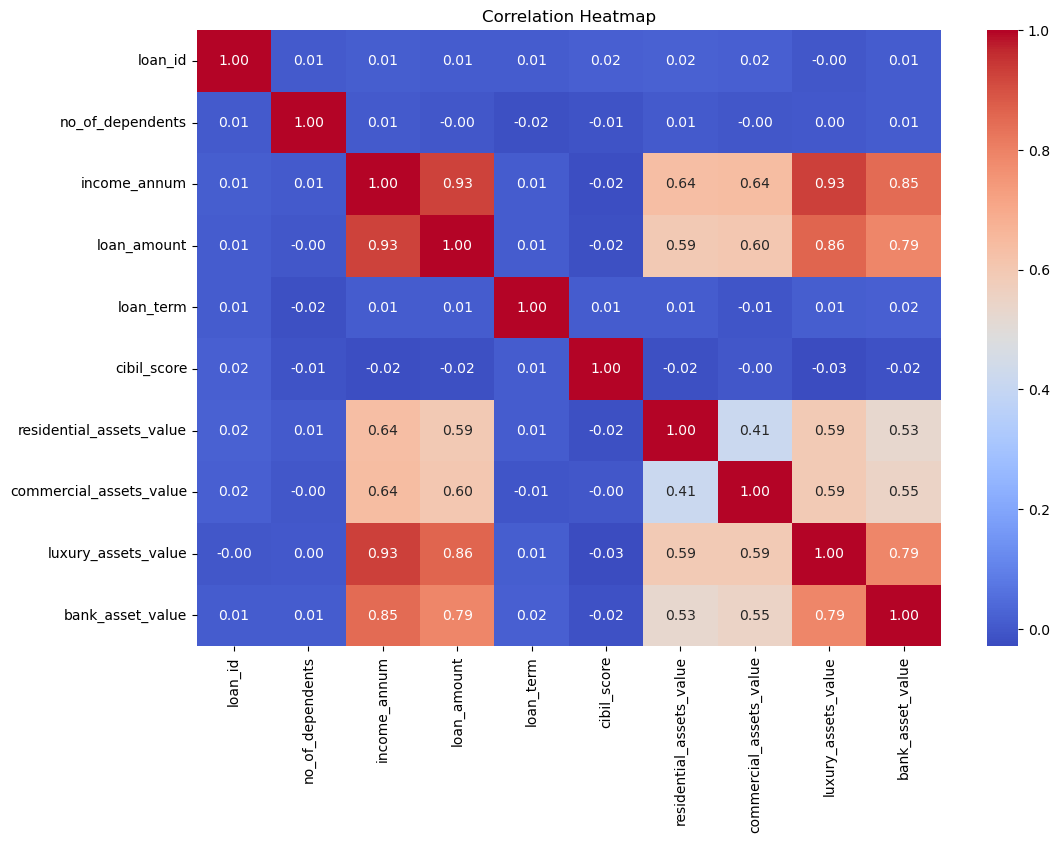

In [63]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

## 🚀 Phase 4 : Data Cleaning

### ```Step 4.1 : Drop Unnecessary Columns```

In [64]:
## remove loan_id
df.drop('loan_id',axis=1,inplace= True)

In [65]:
df.columns

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'loan_status'],
      dtype='object')

#### Step 4.1 : Drop Unnecessary Columns

The `loan_id` column was removed because it is only a unique identifier and does not contribute to predicting loan approval. Keeping identifier columns may introduce unnecessary noise into the machine learning model.

#### Step 4.2 : Missing Value Handling

No missing values were found in the dataset. Therefore, no imputation or missing value treatment was required.

#### Step 4.3 : Duplicate Handling

No duplicate records were found in the dataset. Therefore, duplicate removal was not required.

####  Step 4.4 : Outlier Treatment

Although a few outliers were observed in asset-related features, they appear to represent genuine high-value applicants rather than data errors. Since tree-based algorithms are robust to outliers, no outlier treatment was applied.


##  🚀 Phase 5 : Data Preprocessing

```📌 Step 5.1 : Feature Selection```

In [66]:
X = df.drop('loan_status',axis = 1)
y = df['loan_status']

print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (4269, 11)
y Shape : (4269,)


```📌 Step 5.2 : Build Preprocessing Pipeline```

In [67]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numerical_cols = X.select_dtypes(exclude="object").columns.tolist()

print(categorical_cols)
print(numerical_cols)

['education', 'self_employed']
['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


In [68]:
## apply column transfer
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_cols
        ),
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            categorical_cols
        )
    ]
)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

```📌 Step 5.4 : Train-Test Split```

In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [70]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (3415, 11)
X_test  : (854, 11)
y_train : (3415,)
y_test  : (854,)


In [72]:
X_train = preprocessor.fit_transform(X_train)

X_test = preprocessor.transform(X_test)

In [73]:
print(X_train.shape)
print(X_test.shape)

(3415, 11)
(854, 11)


## 🚀 Phase 6 : Baseline Machine Learning Models

```📌 Step 6.2 : Create Model Dictionary```

In [78]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

models = {
    'Logistic Regression': LogisticRegression(),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Extra Trees': ExtraTreesClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'GaussianNB': GaussianNB(),
    'LDA': LinearDiscriminantAnalysis()
}

for name, model in models.items():

    print("=" * 60)
    print(name)
    print("=" * 60)

    # Train
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {pre:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}\n")

    print("Confusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))
    print("\n")

Logistic Regression
Accuracy : 0.9052
Precision: 0.8786
Recall   : 0.8648
F1 Score : 0.8716

Confusion Matrix
[[498  38]
 [ 43 275]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.93      0.92       536
           1       0.88      0.86      0.87       318

    accuracy                           0.91       854
   macro avg       0.90      0.90      0.90       854
weighted avg       0.90      0.91      0.90       854



KNN
Accuracy : 0.8993
Precision: 0.8473
Recall   : 0.8899
F1 Score : 0.8681

Confusion Matrix
[[485  51]
 [ 35 283]]

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.90      0.92       536
           1       0.85      0.89      0.87       318

    accuracy                           0.90       854
   macro avg       0.89      0.90      0.89       854
weighted avg       0.90      0.90      0.90       854



SVM
Accuracy : 0.9286
Precision: 0.8954
Recall

## Step 6.4 : Baseline Model Comparison

A total of ten baseline machine learning models were trained and evaluated.

Among all the models, Gradient Boosting achieved the highest overall performance with:

- Accuracy : 97.78%
- Precision : 97.46%
- Recall : 96.54%
- F1 Score : 97.00%

```Random Forest``` and Decision Tree also performed exceptionally well, indicating that tree-based ensemble methods are highly effective for this loan approval dataset.

```Linear models``` such as Logistic Regression and LDA achieved comparatively lower performance, suggesting that the relationship between features and the target variable is not purely linear.

### 🚀 Phase 8 : Hyperparameter Tuning

###  ```using Randomized Search cv```

```🚀 Step 8.2 : Hyperparameter Tuning (Random Forest)```

In [80]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
params_dist = {
    "n_estimators":[100,200,300,500],
    "max_depth":[None,10,20,30,40],
    "min_samples_split":[2,5,10],
    "max_features":['sqrt','log2'],
    "bootstrap":[True,False]
}
random_search_rf  = RandomizedSearchCV(
    estimator=rf,
    param_distributions=params_dist,
    n_iter=30,
    scoring="f1",
    cv =5,
    random_state= 42,
    n_jobs=-1
)

random_search_rf .fit(X_train,y_train)
print("Best Parameters :", random_search_rf .best_params_)
print("Best CV Score   :",random_search_rf .best_score_)

Best Parameters : {'n_estimators': 100, 'min_samples_split': 10, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': False}
Best CV Score   : 0.9759362624124547


In [87]:
best_rf = random_search_rf.best_estimator_

y_pred = best_rf.predict(X_test)
print("-"*50)
print("GradientBoostingClassifier")
print("-"*50)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

--------------------------------------------------
GradientBoostingClassifier
--------------------------------------------------
Accuracy : 0.9789227166276346
Precision: 0.9777070063694268
Recall   : 0.9654088050314465
F1 Score : 0.9715189873417721

Confusion Matrix
[[529   7]
 [ 11 307]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       536
           1       0.98      0.97      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



## 8.3 : Decision Tree Hyperparameter Tuning

In [82]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
dt = DecisionTreeClassifier(random_state=42)
params_dist = {
    "criterion": ["gini", "entropy", "log_loss"],
    "splitter": ["best", "random"],
    "max_depth": [None, 5, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": [None, "sqrt", "log2"]
}
random_search_dt = RandomizedSearchCV(
    estimator=dt,
    param_distributions=params_dist,
    n_iter=30,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)
random_search_dt.fit(X_train,y_train)
print("Best Parameters :", random_search_dt.best_params_)
print("Best Score      :", random_search_dt.best_score_)

Best Parameters : {'splitter': 'best', 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': None, 'criterion': 'log_loss'}
Best Score      : 0.9748308228239788


In [92]:
best_rf = random_search_dt.best_estimator_

y_pred = best_rf.predict(X_test)
print("-"*50)
print("DecisionTreeClassifier")
print("-"*50)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

--------------------------------------------------
DecisionTreeClassifier
--------------------------------------------------
Accuracy : 0.977751756440281
Precision: 0.9657320872274143
Recall   : 0.9748427672955975
F1 Score : 0.9702660406885759

Confusion Matrix
[[525  11]
 [  8 310]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       536
           1       0.97      0.97      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



```8.4 : Gradient Boosting Hyperparameter Tuning```

In [94]:
from sklearn.ensemble import  GradientBoostingClassifier
gt = GradientBoostingClassifier(random_state=42)
params_dist = {
    "n_estimators": [50, 100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5],
    "subsample": [0.8, 0.9, 1.0],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}
Gradient_search = RandomizedSearchCV(
    estimator=gt,
    param_distributions=params_dist,
    n_iter=30,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)
Gradient_search.fit(X_train,y_train)
print("Best Parameters :", random_search_dt.best_params_)
print("Best Score      :", random_search_dt.best_score_)

Best Parameters : {'splitter': 'best', 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': None, 'criterion': 'log_loss'}
Best Score      : 0.9748308228239788


In [104]:
best_gb = Gradient_search.best_estimator_

y_pred = best_gb.predict(X_test)
print("-"*50)
print("GradientBoostingClassifier")
print("-"*50)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

--------------------------------------------------
GradientBoostingClassifier
--------------------------------------------------
Accuracy : 0.9871194379391101
Precision: 0.9873015873015873
Recall   : 0.9779874213836478
F1 Score : 0.9826224328593997

Confusion Matrix
[[532   4]
 [  7 311]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       536
           1       0.99      0.98      0.98       318

    accuracy                           0.99       854
   macro avg       0.99      0.99      0.99       854
weighted avg       0.99      0.99      0.99       854



## Step 8.5 : Hyperparameter Tuning Summary

Hyperparameter tuning was performed on the top three baseline models using RandomizedSearchCV.

After tuning, the Gradient Boosting Classifier achieved the best overall performance.

Final Performance:

- Accuracy : 98.71%
- Precision : 98.73%
- Recall : 97.80%
- F1 Score : 98.26%

Compared to the baseline model, hyperparameter tuning significantly improved the model's predictive performance.

Therefore, the tuned Gradient Boosting Classifier was selected as the final model for this project.

## Phase 9 : Final Model Evaluation

In [105]:
best_model = best_gb

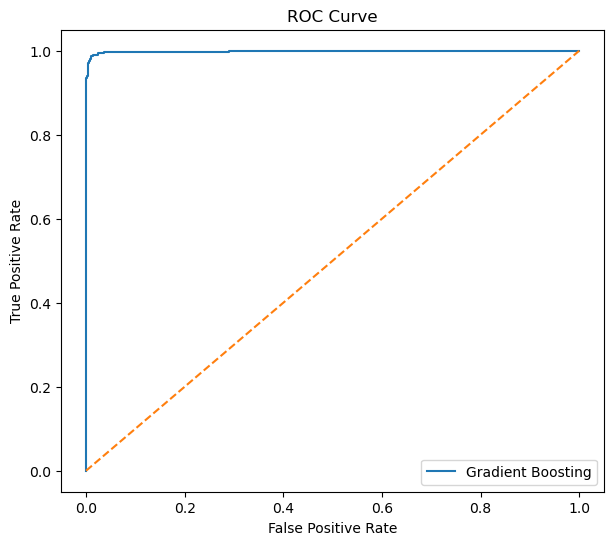

In [106]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label="Gradient Boosting")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

```📌 Step 10.2 : ROC-AUC Score```

In [107]:
auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score : {auc:.4f}")

ROC-AUC Score : 0.9986


```📌 Step 10.3 : Feature Importance```

In [108]:
import pandas as pd

feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
4,num__cibil_score,0.834981
3,num__loan_term,0.082349
2,num__loan_amount,0.043416
1,num__income_annum,0.026162
5,num__residential_assets_value,0.003286
7,num__luxury_assets_value,0.003046
0,num__no_of_dependents,0.002862
6,num__commercial_assets_value,0.001922
8,num__bank_asset_value,0.001901
10,cat__self_employed_ Yes,0.000066


# Conclusion

In this project, a complete end-to-end machine learning pipeline was developed to predict loan approval status.

The workflow included data understanding, exploratory data analysis, data preprocessing, baseline model comparison, hyperparameter tuning, and final model evaluation.

Among all the evaluated models, the tuned Gradient Boosting Classifier achieved the best overall performance.

## Final Model Performance

- Model: Gradient Boosting Classifier
- Accuracy: 98.71%
- Precision: 98.73%
- Recall: 97.80%
- F1 Score: 98.26%

The model demonstrated excellent predictive performance and successfully distinguished between approved and rejected loan applications.

### Business Insights

- Applicants with higher CIBIL scores have a significantly greater chance of loan approval.
- Financial attributes such as annual income, loan amount, and asset values also contribute to loan approval decisions.
- The trained model can help financial institutions automate loan screening, reduce manual effort, and improve decision-making efficiency.

### Future Improvements

- Collect additional real-world customer information.
- Perform feature engineering for better predictive power.
- Explore advanced boosting algorithms such as XGBoost, LightGBM, and CatBoost.
- Deploy the model as a web application using Flask, FastAPI, or Streamlit.